## Problema de frequência

In [14]:
%pip install pulp networkx matplotlib -q

import pulp
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

Note: you may need to restart the kernel to use updated packages.


In [2]:
N = 5  # numero de antenas (vertices)
# arestas (interferências)
edges = [(0,1), (0,2), (1,2), (1,3), (2,4), (3,4)]

In [3]:
G_original = nx.Graph()
G_original.add_nodes_from(range(N))
G_original.add_edges_from(edges)

In [21]:
prob = pulp.LpProblem("Frequencia_Antenas", pulp.LpMinimize)

C = N  # no max N cores (0..N-1)
colors = range(C)

x = [[pulp.LpVariable(f"x_{v}_{c}", cat='Binary') for c in colors] for v in range(N)]
y = [pulp.LpVariable(f"y_{c}", cat='Binary') for c in colors]

# Restrição 1: cada antena usa exatamente uma cor
for v in range(N):
  prob += pulp.lpSum(x[v][c] for c in colors) == 1

# Restrição 2: arestas não podem ter mesma cor
for (u, v) in edges:
  for c in colors:
    prob += x[u][c] + x[v][c] <= 1

# Restrição 3: se alguma antena usa cor c, então y[c] deve ser 1
for v in range(N):
  for c in colors:
    prob += x[v][c] <= y[c]

# Obj: minimizar o número de cores usadas
prob += pulp.lpSum(y[c] for c in colors)

# Resolver
prob.solve(pulp.PULP_CBC_CMD(msg=False))

# Extrair Resultados
colors_used = [c for c in colors if y[c].varValue > 0.5]
n_colors = len(colors_used)

# Atribuição de cor a cada antena
color_of_node = {}
for v in range(N):
  for c in colors:
    if x[v][c].varValue > 0.5:
      color_of_node[v] = c
      break

# Criar DataFrame
df = pd.DataFrame({
  'Antena': list(range(N)),
  'Frequência (Cor)': [color_of_node[v] for v in range(N)]
})

# Resultados
print(f"\nNúmero mínimo de frequências (cores): {n_colors}\n")
print("Atribuição de frequências por antena:")
print(df.to_string(index=False))


Número mínimo de frequências (cores): 3

Atribuição de frequências por antena:
 Antena  Frequência (Cor)
      0                 0
      1                 4
      2                 3
      3                 3
      4                 4


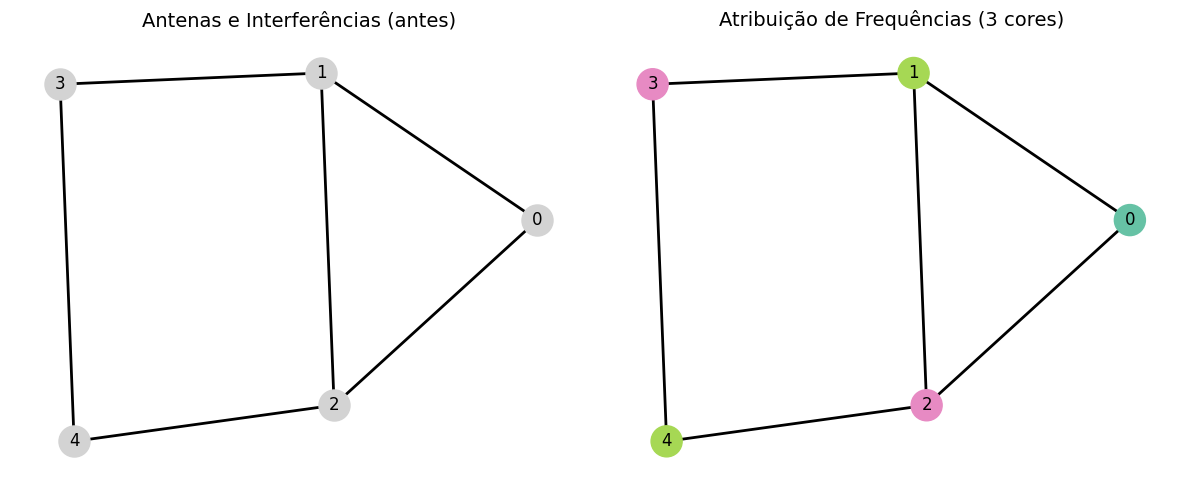

In [13]:
plt.figure(figsize=(12,5))

# Grafo original (sem cores)
plt.subplot(1,2,1)
pos = nx.spring_layout(G_original, seed=42)
nx.draw_networkx_nodes(G_original, pos, node_color='lightgray', node_size=500)
nx.draw_networkx_labels(G_original, pos, font_size=12)
nx.draw_networkx_edges(G_original, pos, edge_color='black', width=2, arrows=False)
plt.title("Antenas e Interferências (antes)", fontsize=14)
plt.axis('off')

# Grafo colorido
plt.subplot(1,2,2)
# Mapear cores numéricas para matplotlib colors
cmap = plt.cm.Set2
node_colors = [cmap(color_of_node[v] % 9) for v in range(N)]  # %9 para caber na paleta
nx.draw_networkx_nodes(G_original, pos, node_color=node_colors, node_size=500)
nx.draw_networkx_labels(G_original, pos, font_size=12)
nx.draw_networkx_edges(G_original, pos, edge_color='black', width=2, arrows=False)
plt.title(f"Atribuição de Frequências ({n_colors} cores)", fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()